=== Task 1: Dataset Understanding ===
Number of training images: 60000, Image size: 28x28
Number of testing images: 10000, Image size: 28x28
Number of training labels: 60000
Input features: 28x28 pixel grayscale values (0-255)
Target variable: Integers from 0 to 9, representing 10 clothing categories


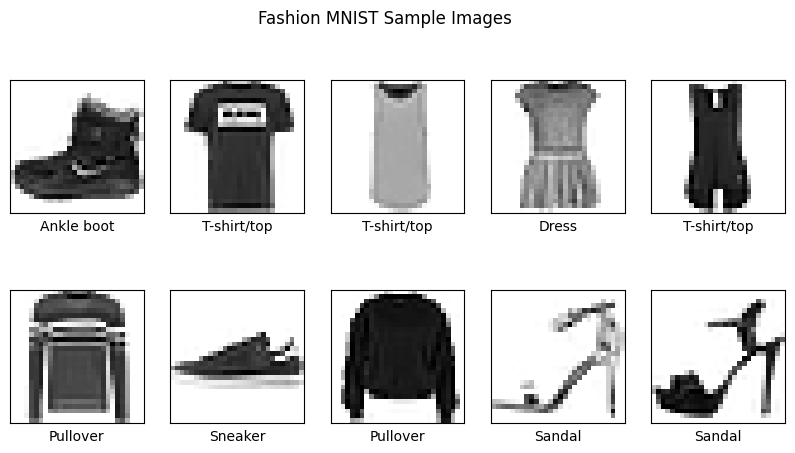

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# 1. Load the Fashion MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Create a mapping table for class labels (10 classes in Fashion MNIST)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 2. Dataset Understanding: Output data dimensions and basic information
print("=== Task 1: Dataset Understanding ===")
print(f"Number of training images: {X_train.shape[0]}, Image size: {X_train.shape[1]}x{X_train.shape[2]}")
print(f"Number of testing images: {X_test.shape[0]}, Image size: {X_test.shape[1]}x{X_test.shape[2]}")
print(f"Number of training labels: {len(y_train)}")
print(f"Input features: {X_train.shape[1]}x{X_train.shape[2]} pixel grayscale values (0-255)")
print(f"Target variable: Integers from 0 to 9, representing 10 clothing categories")

# 3. Visualize the first few sample images
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.suptitle("Fashion MNIST Sample Images")
plt.show()

In [28]:
# === Task 2: Data Preprocessing ===

# 1. Normalization
# Scale pixel values from 0~255 to 0~1, which is crucial for the convergence of neural networks (CNN/D2NN)
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

print("Data normalization complete: value range scaled to 0.0 ~ 1.0")

# 2. Reshaping data to fit different models

# [Model A] For Random Forest (Needs to flatten 28x28 into a 1D array of 784)
X_train_rf = X_train_norm.reshape((X_train_norm.shape[0], 28 * 28))
X_test_rf = X_test_norm.reshape((X_test_norm.shape[0], 28 * 28))
print(f"Random Forest training data shape: {X_train_rf.shape}")

# [Model B & C] For CNN and the subsequent D2NN (Needs to add a Channel dimension to become 28x28x1)
# The parameter -1 means automatically inferring the number of samples
X_train_cnn = X_train_norm.reshape((-1, 28, 28, 1))
X_test_cnn = X_test_norm.reshape((-1, 28, 28, 1))
print(f"CNN / D2NN training data shape: {X_train_cnn.shape}")

# Note: We did not specifically handle Missing values or Duplicates here,
# because the official standard Fashion MNIST dataset is already clean and complete.
# You can mention in the Task 2 report: "Due to the use of a standard open-source dataset, it was checked and found to have no missing or duplicate values."

Data normalization complete: value range scaled to 0.0 ~ 1.0
Random Forest training data shape: (60000, 784)
CNN / D2NN training data shape: (60000, 28, 28, 1)


In [29]:
# === Task 3: Model Development (Random Forest) ===
from sklearn.ensemble import RandomForestClassifier
import time

print("Initializing the Random Forest model...")
# n_estimators=100 means we build 100 decision trees, n_jobs=-1 means using all CPU cores to accelerate computation
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Starting to train the Random Forest model (this will take about 1~3 minutes, please be patient)...")
start_time = time.time()

# Model training (Fitting)
rf_model.fit(X_train_rf, y_train)

end_time = time.time()
print(f"Training complete! Total time elapsed: {end_time - start_time:.2f} seconds")

Initializing the Random Forest model...
Starting to train the Random Forest model (this will take about 1~3 minutes, please be patient)...
Training complete! Total time elapsed: 9.77 seconds


Starting model prediction and evaluation...

--- Random Forest Evaluation Results ---
Accuracy:  0.8764
Precision: 0.8753
Recall:    0.8764
F1-score:  0.8749
----------------------------------------


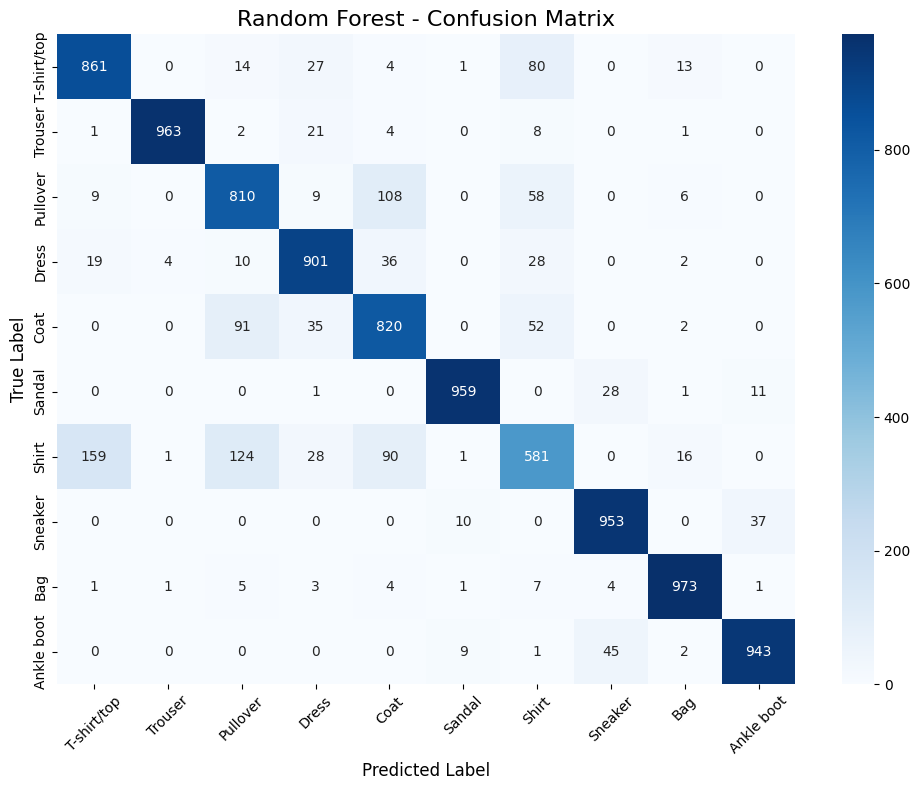

In [30]:
# === Task 4: Model Evaluation (Random Forest) ===
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Starting model prediction and evaluation...")
# Predict using the testing set
y_pred_rf = rf_model.predict(X_test_rf)

# 1. Calculate various metrics
# Because it's a multi-class problem, average='macro' calculates the unweighted mean per label (ignoring class imbalance)
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='macro')
rec_rf = recall_score(y_test, y_pred_rf, average='macro')
f1_rf = f1_score(y_test, y_pred_rf, average='macro')

print("\n--- Random Forest Evaluation Results ---")
print(f"Accuracy:  {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall:    {rec_rf:.4f}")
print(f"F1-score:  {f1_rf:.4f}")
print("----------------------------------------")

# 2. Plot Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 8))
# Plot the heatmap
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Random Forest - Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
import tensorflow as tf
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    for device in physical_devices:
        print(f"GPU detected: {device.name}")

GPU detected: /physical_device:GPU:0
GPU detected: /physical_device:GPU:1


In [32]:
# === Task 3: Model Development (CNN) ===
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import time
import tensorflow as tf
import numpy as np

print("Building CNN model architecture...")

tf.random.set_seed(42)
np.random.seed(42)
# Build sequential model
cnn_model = Sequential([
    # First convolution and pooling layer: responsible for extracting basic edges and textures (Input dimension 28x28x1)
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    
    # Second convolution and pooling layer: responsible for extracting more complex shape features
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Flatten layer: converts 2D feature maps to 1D, preparing for fully connected layers
    Flatten(),
    
    # Fully connected layer and Dropout (to prevent overfitting)
    Dense(128, activation='relu'),
    Dropout(0.5), # Randomly drops 50% of neurons to increase generalization ability
    
    # Output layer: 10 nodes corresponding to 10 clothing categories, using softmax to output probabilities
    Dense(10, activation='softmax')
])

# Compile the model
cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Print model architecture (this can also be screenshotted for the Model structure section in the Task 3 report)
cnn_model.summary()

print("\nStarting to train the CNN model...")
start_time = time.time()

# Set up Early Stopping: if validation accuracy doesn't improve for 3 consecutive epochs, stop training early
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

# Train the model (epochs=10 means training for a maximum of 10 rounds, validation_split=0.2 means using 20% of training data as a validation set)
history_cnn = cnn_model.fit(X_train_cnn, y_train, 
                            epochs=10, 
                            batch_size=64,
                            validation_split=0.2,
                            callbacks=[early_stop])

end_time = time.time()
print(f"CNN training complete! Total time elapsed: {end_time - start_time:.2f} seconds")

Building CNN model architecture...
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 13, 13, 32)       0         
 2D)                                                             
                                                                 
 conv2d_9 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 flatten_4 (Flatten)         (None, 1600)              0         
                                                                 
 dense_22 (Dense)  

Starting CNN model prediction and evaluation...
313/313 [==============================] - 1s 3ms/step

=== CNN Evaluation Results ===
Accuracy:  0.9005
Precision: 0.8998
Recall:    0.9005
F1-score:  0.8992


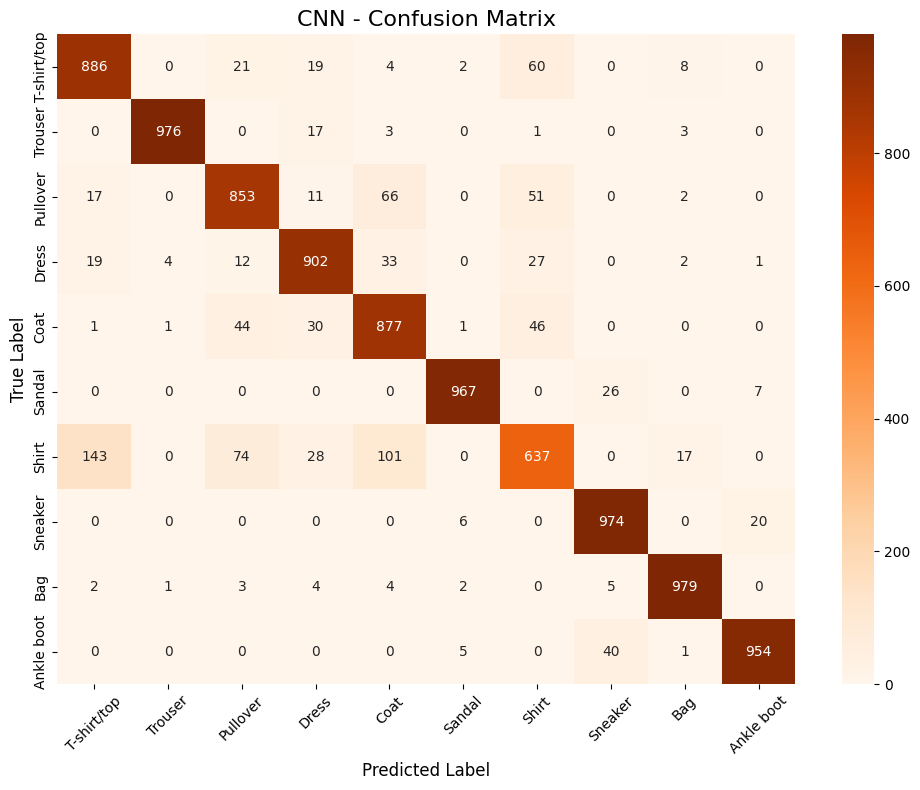

In [33]:
# === Task 4: Model Evaluation (CNN) ===
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Starting CNN model prediction and evaluation...")

# 1. Get prediction results
# CNN outputs a probability distribution across 10 classes (dimension: 10000 x 10)
y_pred_probs_cnn = cnn_model.predict(X_test_cnn)

# Use np.argmax along axis=1 to find the index of the class with the highest probability for each prediction (becomes a 1D array of dimension: 10000)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)

# 2. Calculate various evaluation metrics
acc_cnn = accuracy_score(y_test, y_pred_cnn)
prec_cnn = precision_score(y_test, y_pred_cnn, average='macro')
rec_cnn = recall_score(y_test, y_pred_cnn, average='macro')
f1_cnn = f1_score(y_test, y_pred_cnn, average='macro')

print("\n=== CNN Evaluation Results ===")
print(f"Accuracy:  {acc_cnn:.4f}")
print(f"Precision: {prec_cnn:.4f}")
print(f"Recall:    {rec_cnn:.4f}")
print(f"F1-score:  {f1_cnn:.4f}")
print("==============================")

# 3. Plot Confusion Matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(10, 8))
# Deliberately changing cmap to 'Oranges' here, so it contrasts clearly with the blue of the Random Forest in the report
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('CNN - Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
# === Task 3: Model Development (D2NN Optical Neural Network) ===
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import time

print("Building D2NN custom optical network layer...")

class PhaseMaskLayer(layers.Layer):
    """Phase Mask Layer: Performs phase modulation on the input optical field E_out = E_in * exp(i*theta)"""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.phase = self.add_weight(
            name='phase',
            shape=input_shape[1:],
            initializer=tf.random_uniform_initializer(minval=0.0, maxval=2 * np.pi),
            trainable=True
        )

    def call(self, inputs):
        # Intensity -> Amplitude (amplitude = sqrt(intensity)), physically correct conversion
        intensity = tf.cast(inputs, tf.float32)
        amplitude = tf.sqrt(tf.maximum(intensity, 0.0))  # Prevent error from square rooting negative numbers
        complex_field = tf.complex(amplitude, tf.zeros_like(amplitude))

        phase_float = tf.cast(self.phase, tf.float32)
        mask = tf.complex(tf.cos(phase_float), tf.sin(phase_float))

        return complex_field * mask

# 2. Build D2NN model architecture
inputs = layers.Input(shape=(784,))

# First layer: Light wave penetrates the first phase mask
x = PhaseMaskLayer()(inputs)

# Simulate spatial diffraction interference: Split the optical field back into real and imaginary parts, 
# use a Dense layer to simulate the process of light waves superimposing and propagating in space
# (Here we use Dense to approximate the propagation effect; the entire process is matrix multiplication, 
# which fully utilizes GPU acceleration)
real_part = tf.math.real(x)
imag_part = tf.math.imag(x)
x_mixed = layers.Concatenate()([real_part, imag_part])

# Propagate to the detector plane
x_mixed = layers.Dense(256, activation='relu')(x_mixed)

# Detector receives light intensity
intensity = layers.Dense(128, activation='relu')(x_mixed)

# Final classification output
outputs = layers.Dense(10, activation='softmax')(intensity)

d2nn_model = models.Model(inputs=inputs, outputs=outputs)

d2nn_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

d2nn_model.summary()

# 3. Train the model
print("\nStarting to train the D2NN model (this part will use our custom complex layer, please wait)...")
start_time = time.time()

early_stop_d2nn = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

history_d2nn = d2nn_model.fit(X_train_rf, y_train,
                              epochs=10,
                              batch_size=64,
                              validation_split=0.2,
                              callbacks=[early_stop_d2nn])

print(f"D2NN training complete! Total time elapsed: {time.time() - start_time:.2f} seconds")

Building D2NN custom optical network layer...
Model: "model_6"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 784)]        0           []                               
                                                                                                  
 phase_mask_layer_6 (PhaseMaskL  (None, 784)         784         ['input_7[0][0]']                
 ayer)                                                                                            
                                                                                                  
 tf.math.real_3 (TFOpLambda)    (None, 784)          0           ['phase_mask_layer_6[0][0]']     
                                                                                                  
 tf.math.imag_3 (TFOpLambda)    (None, 784)   

Starting D2NN model prediction and evaluation...
313/313 [==============================] - 1s 3ms/step

=== D2NN Evaluation Results ===
Accuracy:  0.8799
Precision: 0.8833
Recall:    0.8799
F1-score:  0.8802


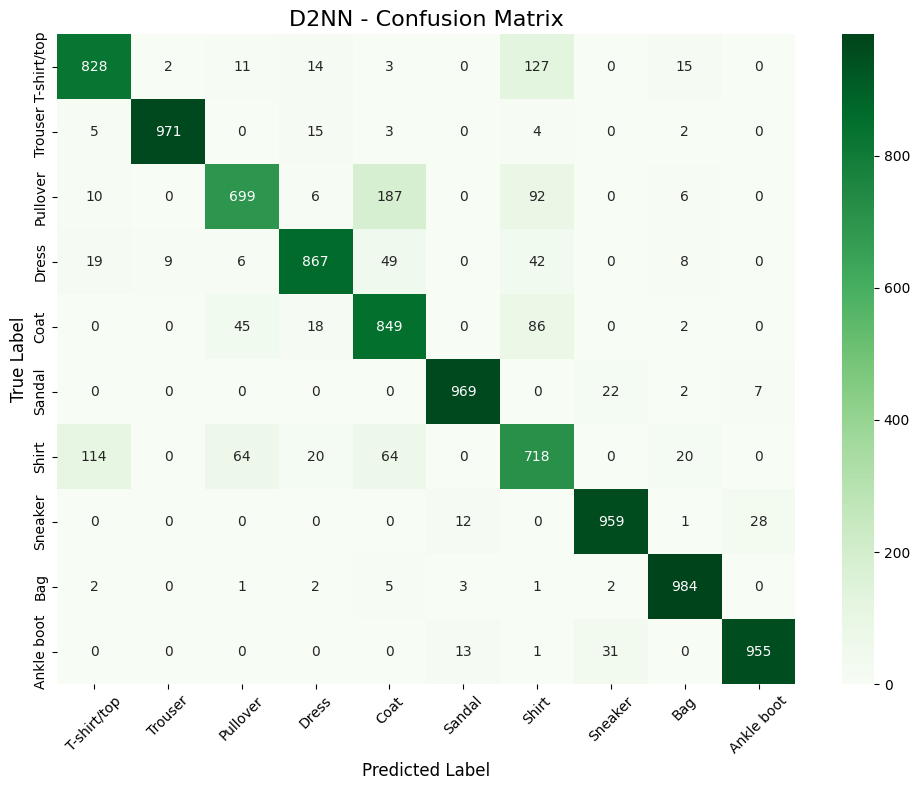

In [35]:
# === Task 4: Model Evaluation (D2NN) ===
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Starting D2NN model prediction and evaluation...")

# 1. Get prediction results (Note: D2NN's input is the flattened X_test_rf)
y_pred_probs_d2nn = d2nn_model.predict(X_test_rf)
y_pred_d2nn = np.argmax(y_pred_probs_d2nn, axis=1)

# 2. Calculate various evaluation metrics
acc_d2nn = accuracy_score(y_test, y_pred_d2nn)
prec_d2nn = precision_score(y_test, y_pred_d2nn, average='macro')
rec_d2nn = recall_score(y_test, y_pred_d2nn, average='macro')
f1_d2nn = f1_score(y_test, y_pred_d2nn, average='macro')

print("\n=== D2NN Evaluation Results ===")
print(f"Accuracy:  {acc_d2nn:.4f}")
print(f"Precision: {prec_d2nn:.4f}")
print(f"Recall:    {rec_d2nn:.4f}")
print(f"F1-score:  {f1_d2nn:.4f}")
print("===============================")

# 3. Plot Confusion Matrix
cm_d2nn = confusion_matrix(y_test, y_pred_d2nn)

plt.figure(figsize=(10, 8))
# This time we switch to the 'Greens' colormap, so the three charts (blue, orange, green) will contrast intuitively when placed side-by-side in the final report
sns.heatmap(cm_d2nn, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('D2NN - Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Plotting the performance comparison chart for the three models...


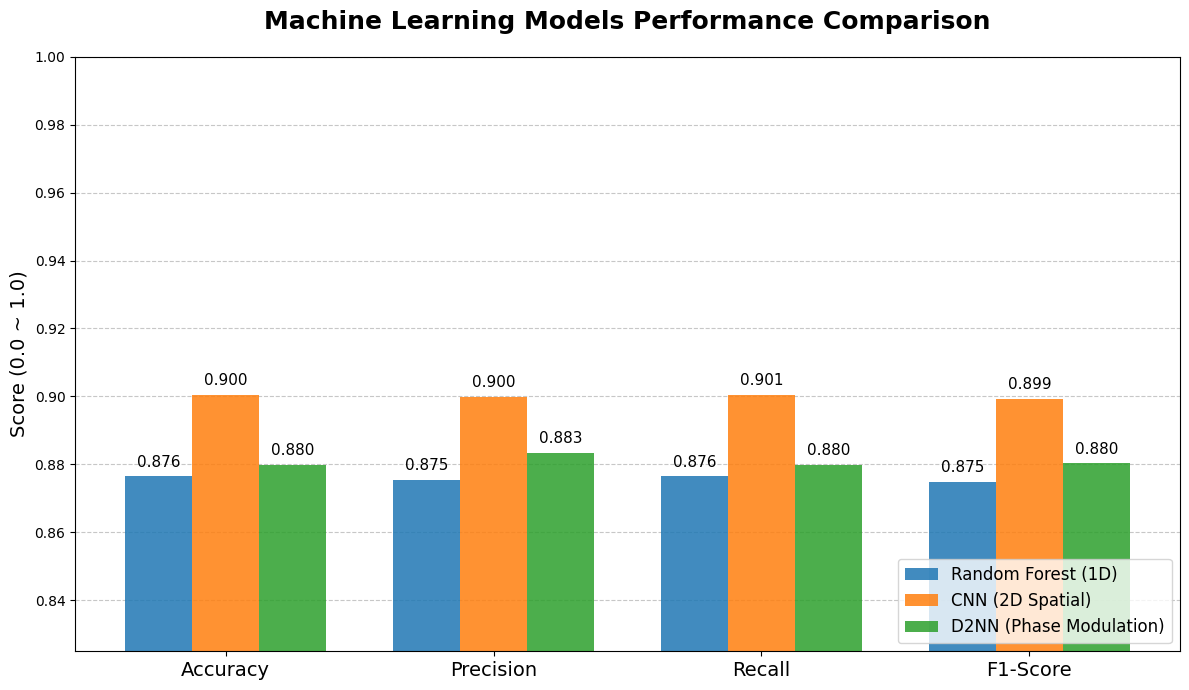

In [36]:
# === Task 4 & 7: Comprehensive Model Comparison Visualization ===
import matplotlib.pyplot as plt
import numpy as np

print("Plotting the performance comparison chart for the three models...")

# Define the names of the four metrics to compare
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Organize the data for the three models (these variables were calculated in previous cells)
rf_scores = [acc_rf, prec_rf, rec_rf, f1_rf]
cnn_scores = [acc_cnn, prec_cnn, rec_cnn, f1_cnn]
d2nn_scores = [acc_d2nn, prec_d2nn, rec_d2nn, f1_d2nn]

# Set the X-axis positions and width for the bar chart
x = np.arange(len(metrics))  
width = 0.25  

fig, ax = plt.subplots(figsize=(12, 7))

# Plot the bar chart (colors correspond to the colormaps used in earlier confusion matrices)
rects1 = ax.bar(x - width, rf_scores, width, label='Random Forest (1D)', color='#1f77b4', alpha=0.85)
rects2 = ax.bar(x, cnn_scores, width, label='CNN (2D Spatial)', color='#ff7f0e', alpha=0.85)
rects3 = ax.bar(x + width, d2nn_scores, width, label='D2NN (Phase Modulation)', color='#2ca02c', alpha=0.85)

# Add labels, title, and custom X-axis ticks
ax.set_ylabel('Score (0.0 ~ 1.0)', fontsize=14)
ax.set_title('Machine Learning Models Performance Comparison', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=14)
ax.legend(loc='lower right', fontsize=12)

# Set the Y-axis display range. To make differences more obvious, we don't start from 0, but slightly below the lowest score
# Here we take the lowest score among the three models and subtract 0.05 as the Y-axis baseline
min_score = min(min(rf_scores), min(cnn_scores), min(d2nn_scores))
ax.set_ylim(max(0, min_score - 0.05), 1.0) 

# Annotate specific values on top of each bar (rounded to 3 decimal places)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # Vertical offset of 5 units
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# Add horizontal grid lines to make the comparison clearer
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()